In [40]:
# ============================================================
# Gödel implication
# ============================================================

def godel_implication(a, b):
    """
    Gödel implication:

        a ->_G b = 1, if a <= b,
                 = b, otherwise.

    This implication satisfies the left neutrality principle:
        1 ->_G b = b.
    """
    return np.where(a <= b, 1.0, b)

# ============================================================
# Product implication
# ============================================================

def product_implication(a, b):
    """
    Product implication:

        a ->_P b = 1, if a <= b,
                 = b/a, otherwise.
    """
    return np.where(a <= b, 1.0, b / a)


# ============================================================
# T-norms
# ============================================================

def product_tnorm(a, b):
    return a * b


def minimum_tnorm(a, b):
    return np.minimum(a, b)


# ============================================================
# Łukasiewicz t-norm and implication
# ============================================================

def lukasiewicz_tnorm(a, b):
    """
    Łukasiewicz t-norm:

        a ⊗_L b = max(0, a + b - 1).
    """
    return np.maximum(0.0, a + b - 1.0)


def lukasiewicz_implication(a, b):
    """
    Łukasiewicz implication:

        a ->_L b = min(1, 1 - a + b).
    """
    return np.minimum(1.0, 1.0 - a + b)


x-centers: [-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.  ]
y-centers: [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.    1.25  1.5   1.75
  2.    2.25  2.5   2.75  3.  ]


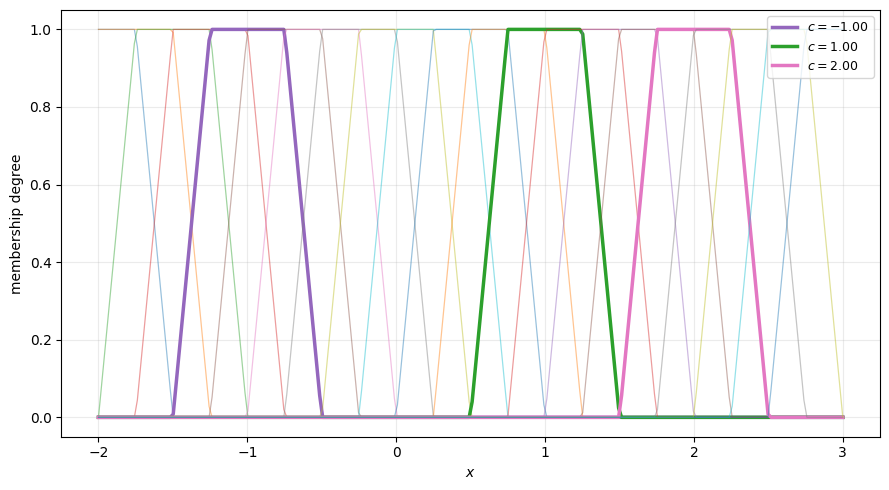

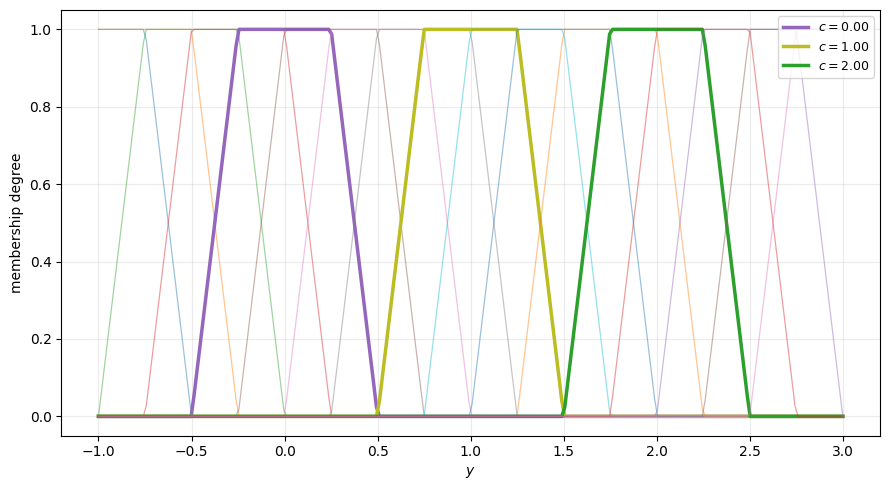

C:\Users\Dankova.MS\AppData\Local\Temp\ipykernel_11352\1391521834.py:28: RuntimeWarning: divide by zero encountered in divide
  return np.where(a <= b, 1.0, b / a)


Approximation of R1
-------------------
delta1: 0.25
number of x-centers: 21
number of y-centers: 17
maximum error: 0.3613389725347008
mean error: 0.05131198561888411

Approximation of R2
-------------------
delta1: 0.25
number of x-centers: 21
number of y-centers: 17
maximum error: 0.9799196787148592
mean error: 0.1836303212851406


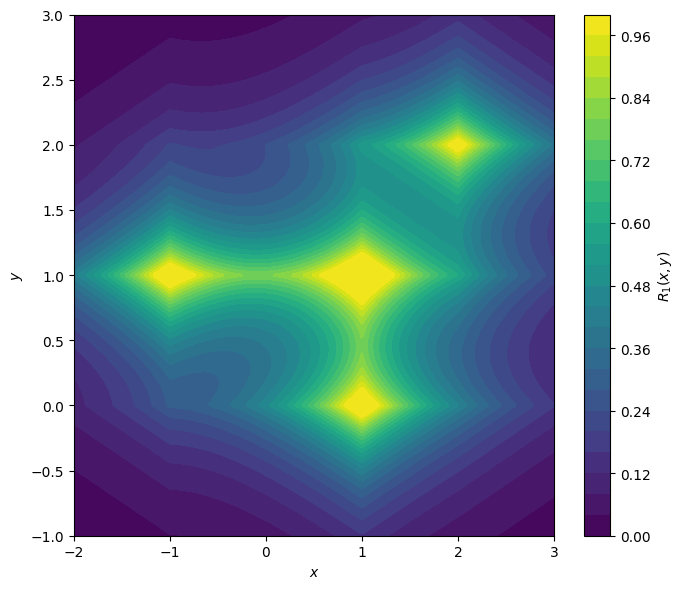

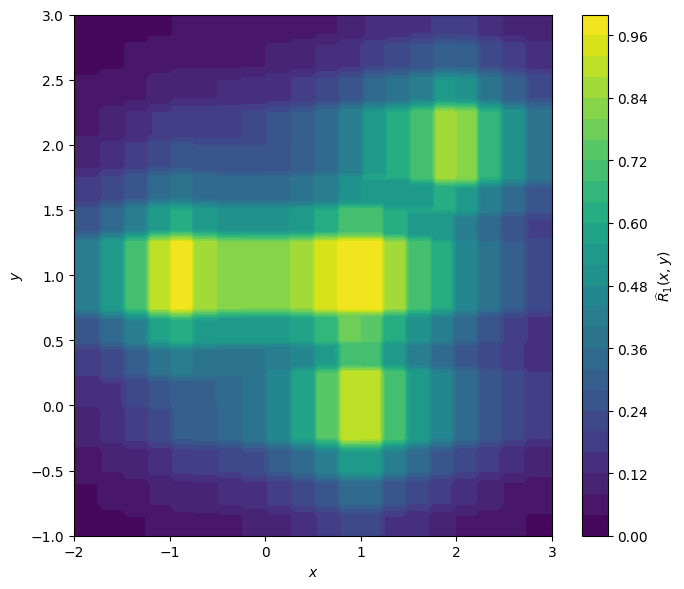

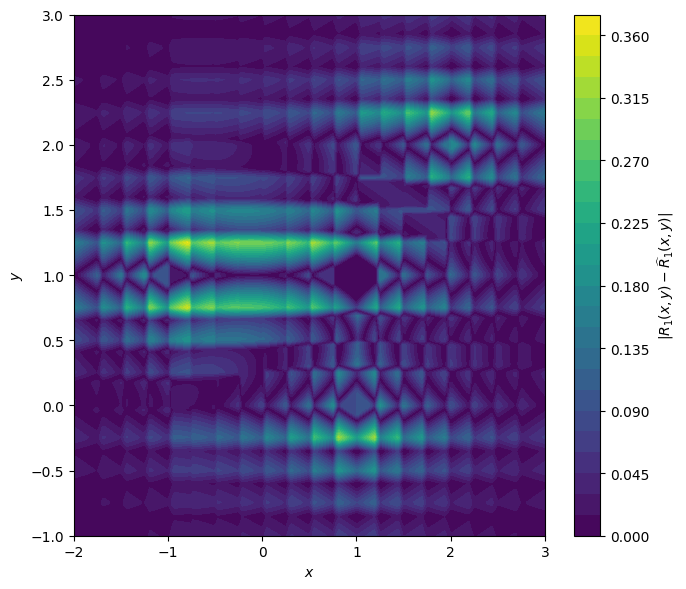

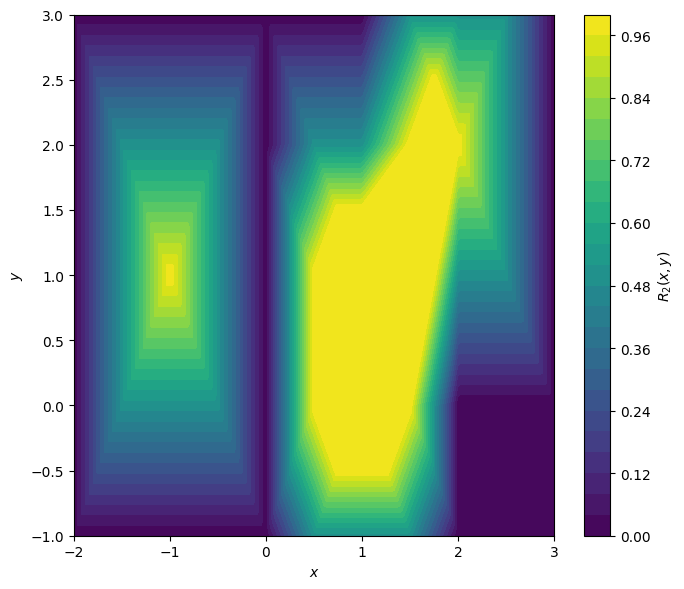

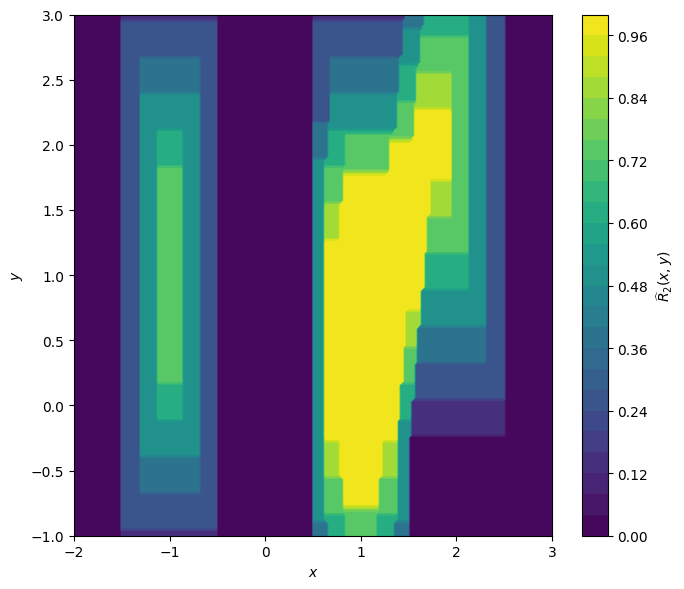

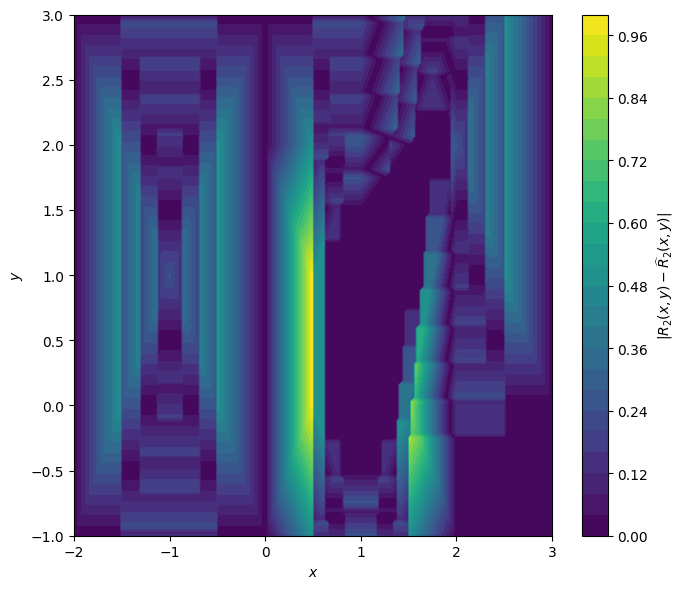

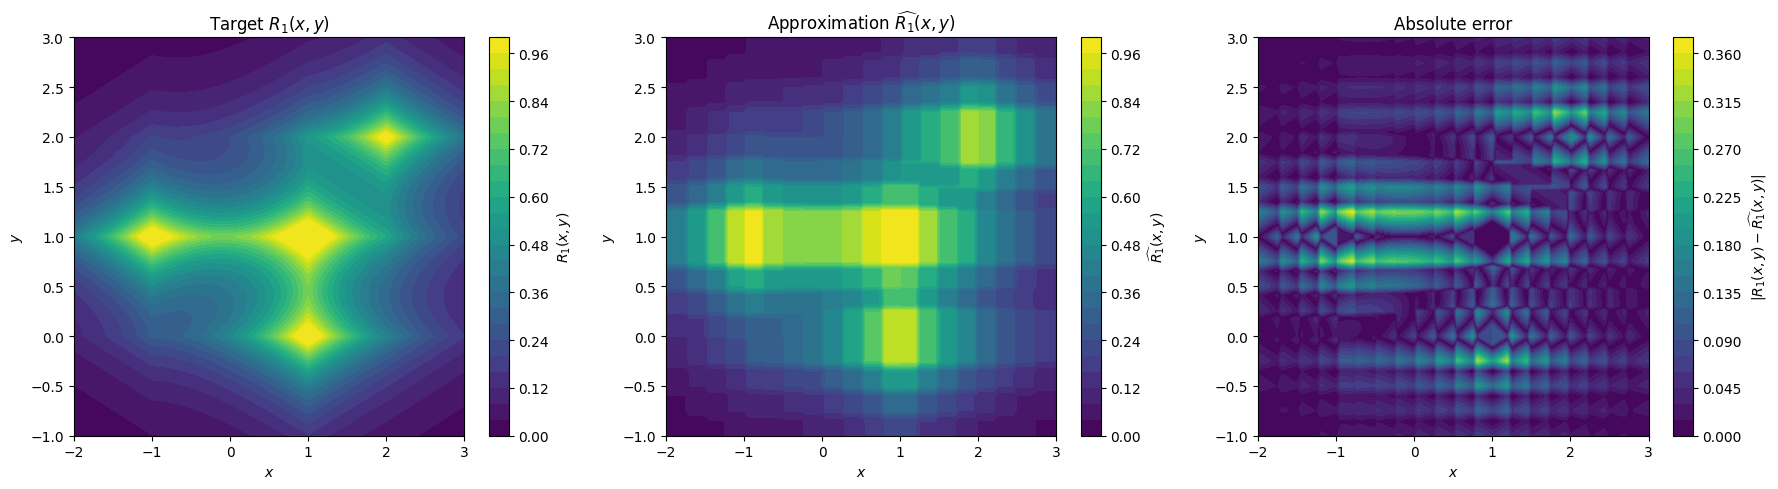

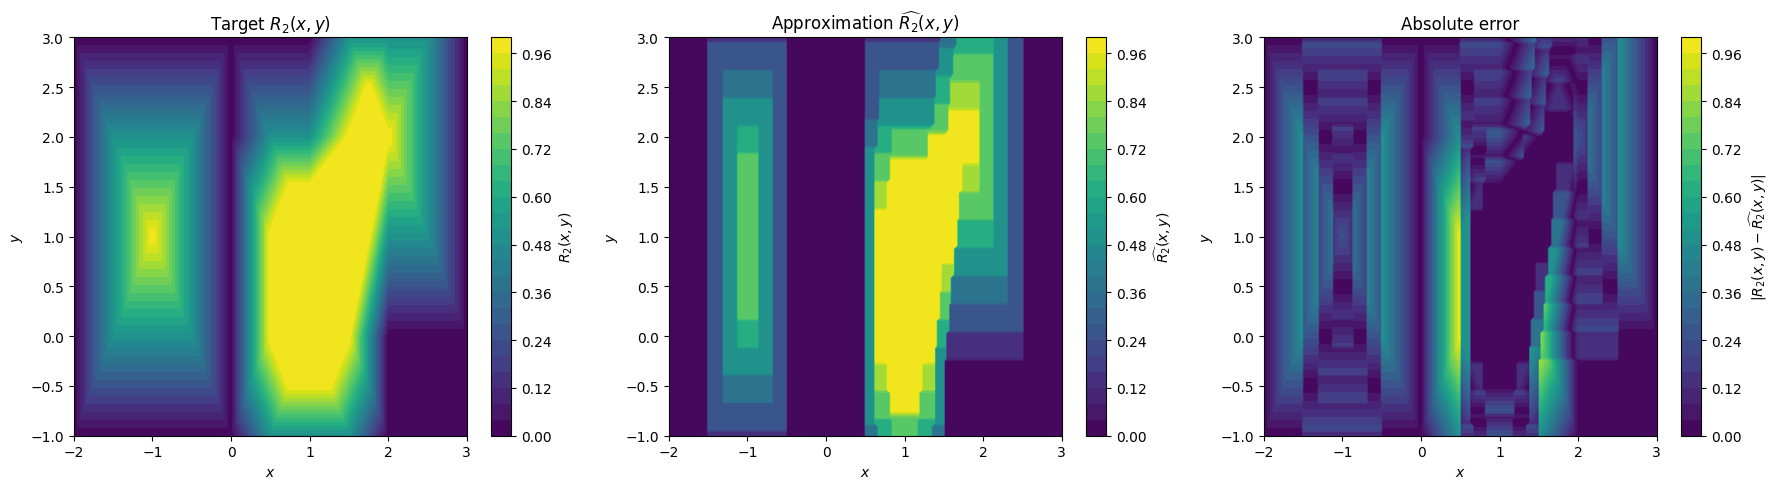

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Output folder
# ============================================================

os.makedirs("img", exist_ok=True)


# ============================================================
# Data matrix
# ============================================================

D = np.array([
    [-1, 1],
    [1, 0],
    [1, 1],
    [2, 2]
])


# ============================================================
# Target fuzzy relations R1 and R2
# ============================================================

def R1(x, y):
    """
    Exponential kernels with product t-norm.

    R1(x,y) =
        min(1, sum_i exp(-|x_i-x|) exp(-2|y_i-y|))
    """
    total = 0

    for xi, yi in D:
        f1 = np.exp(-np.abs(xi - x))
        #f2 = np.exp(-np.abs(yi - y))
        f2 = np.exp(-2 * np.abs(yi - y))
        total += f1 * f2

    return np.minimum(1, total)


def R2(x, y):
    """
    Triangular kernels with minimum t-norm.

    R2(x,y) =
         min(1, sum_i min(
            max(1-|x_i-x|,0),
            max(1-|y_i-y|/2,0)
        ))
    """
    total = 0

    for xi, yi in D:
        f1 = np.maximum(1 - np.abs(xi - x), 0)
        #f2 = np.maximum(1 - np.abs(yi - y), 0)
        f2 = np.maximum(1 - np.abs(yi - y) / 2, 0)
        total += np.minimum(f1, f2)

    return np.minimum(1, total)



# ============================================================
# Fuzzy balls A_x and B_y from the theorem
# ============================================================

def fuzzy_ball(z, center, delta1):
    """
    Implements the fuzzy set

        A_center(z) = min(1, max(0, 2 - |z-center|/delta1)).

    If |z-center| < delta1, then A_center(z) = 1.
    If |z-center| >= 2 delta1, then A_center(z) = 0.
    """
    return np.minimum(
        1.0,
        np.maximum(0.0, 2.0 - np.abs(z - center) / delta1)
    )

# ============================================================
# Plot all fuzzy balls used in the approximation
# ============================================================

def plot_fuzzy_balls_1d(
    grid,
    centers,
    delta1,
    variable_name,
    filename,
    selected_centers=None
):
    """
    Plots all fuzzy balls A_c(z) = min(1, max(0, 2 - |z-c|/delta1))
    used in the implementation.

    Parameters
    ----------
    grid : np.ndarray
        One-dimensional grid on which the fuzzy balls are evaluated.
    centers : np.ndarray
        Centers of the fuzzy balls.
    delta1 : float
        Radius parameter used in fuzzy_ball.
    variable_name : str
        Name of the variable, e.g. 'x' or 'y'.
    filename : str
        Output filename.
    selected_centers : list or None
        Optional list of centers to emphasize.
    """

    plt.figure(figsize=(9, 5))

    for c in centers:
        values = fuzzy_ball(grid, c, delta1)

        if selected_centers is not None and np.any(np.isclose(c, selected_centers)):
            plt.plot(
                grid,
                values,
                linewidth=2.5,
                label=rf"$c={c:.2f}$"
            )
        else:
            plt.plot(
                grid,
                values,
                linewidth=0.9,
                alpha=0.45
            )

    plt.xlabel(rf"${variable_name}$")
    plt.ylabel(r"membership degree")
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.25)

    if selected_centers is not None:
        plt.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()

# ============================================================
# Weighted implicative approximation
# ============================================================

def weighted_implicative_approximation(
    X,
    Y,
    R_target,
    x_centers,
    y_centers,
    delta1,
    conjunction=minimum_tnorm,
    implication=product_implication
):
    """
    Computes

        R_hat(s,t)
        =
        inf_{A_x in A}
        [
            A_x(s) -> sup_{B_y in B}
            ( q(A_x,B_y) conjunction B_y(t) )
        ],

    where

        q(A_x,B_y) = R_target(x,y).

    In the discrete numerical implementation:
        inf = minimum,
        sup = maximum.
    """

    R_hat = np.ones_like(X)

    # Quantifier table Q[i,j] = q(A_x_i, B_y_j) = R(x_i,y_j)
    Q = np.zeros((len(x_centers), len(y_centers)))

    for i, cx in enumerate(x_centers):
        for j, cy in enumerate(y_centers):
            Q[i, j] = R_target(cx, cy)

    # Compute infimum over antecedent fuzzy sets A_x
    for i, cx in enumerate(x_centers):

        A_i = fuzzy_ball(X, cx, delta1)

        # Compute supremum over consequent fuzzy sets B_y
        inner_sup = np.zeros_like(X)

        for j, cy in enumerate(y_centers):

            B_j = fuzzy_ball(Y, cy, delta1)

            value = conjunction(Q[i, j], B_j)

            inner_sup = np.maximum(inner_sup, value)

        F_i = implication(A_i, inner_sup)

        R_hat = np.minimum(R_hat, F_i)

    return R_hat


# ============================================================
# Compact domains and computational grid
# ============================================================

x_min, x_max = -2, 3
y_min, y_max = -1, 3

n_grid = 250

x = np.linspace(x_min, x_max, n_grid)
y = np.linspace(y_min, y_max, n_grid)

X, Y = np.meshgrid(x, y)


# ============================================================
# Finite coverings of X and Y
# ============================================================

# Smaller delta1 means more fuzzy sets and usually better approximation.
# Try, for example:
# delta1 = 0.5
# delta1 = 0.35
# delta1 = 0.25
# delta1 = 0.2

delta1 = 0.25
#------------------------------
# Define centers of fuzzy balls with a small margin outside the grid
#------------------------------
x_centers = np.arange(x_min,x_max + 2*delta1, 2*delta1)
y_centers = np.arange(y_min, y_max + 2*delta1, 2*delta1)

#x_centers = np.arange(x_min,x_max + delta1, delta1)
#y_centers = np.arange(y_min, y_max + delta1, delta1)

print("x-centers:", x_centers)
print("y-centers:", y_centers)
plot_fuzzy_balls_1d(
    grid=x,
    centers=x_centers,
    delta1=delta1,
    variable_name="x",
    filename="img/fuzzy_balls_x.png",
    selected_centers=[-1, 1, 2]
)

plot_fuzzy_balls_1d(
    grid=y,
    centers=y_centers,
    delta1=delta1,
    variable_name="y",
    filename="img/fuzzy_balls_y.png",
    selected_centers=[0, 1, 2]
)
# ============================================================
# Compute target relations
# ============================================================

Z1 = R1(X, Y)
Z2 = R2(X, Y)


# ============================================================
# Compute approximations
# ============================================================

Z1_hat = weighted_implicative_approximation(
    X=X,
    Y=Y,
    R_target=R1,
    x_centers=x_centers,
    y_centers=y_centers,
    delta1=delta1,
    conjunction=product_tnorm,
    implication=product_implication
)

Z2_hat = weighted_implicative_approximation(
    X=X,
    Y=Y,
    R_target=R2,
    x_centers=x_centers,
    y_centers=y_centers,
    delta1=delta1,
    conjunction=minimum_tnorm,
    implication=godel_implication
)


# ============================================================
# Errors
# ============================================================

E1 = np.abs(Z1 - Z1_hat)
E2 = np.abs(Z2 - Z2_hat)

print("Approximation of R1")
print("-------------------")
print("delta1:", delta1)
print("number of x-centers:", len(x_centers))
print("number of y-centers:", len(y_centers))
print("maximum error:", np.max(E1))
print("mean error:", np.mean(E1))
print()

print("Approximation of R2")
print("-------------------")
print("delta1:", delta1)
print("number of x-centers:", len(x_centers))
print("number of y-centers:", len(y_centers))
print("maximum error:", np.max(E2))
print("mean error:", np.mean(E2))


# ============================================================
# Plotting functions
# ============================================================

def save_contour(Z, title, colorbar_label, filename):
    plt.figure(figsize=(7, 6))
    plt.contourf(X, Y, Z, levels=30)
    plt.colorbar(label=colorbar_label)
    #plt.title(title)
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()


def save_comparison(Z, Z_hat, E, relation_name, filename):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    panels = [
        (
            Z,
            rf"Target ${relation_name}(x,y)$",
            rf"${relation_name}(x,y)$"
        ),
        (
            Z_hat,
            rf"Approximation $\widehat{{{relation_name}}}(x,y)$",
            rf"$\widehat{{{relation_name}}}(x,y)$"
        ),
        (
            E,
            "Absolute error",
            rf"$|{relation_name}(x,y)-\widehat{{{relation_name}}}(x,y)|$"
        )
    ]

    for ax, (Z_current, title, label) in zip(axes, panels):
        c = ax.contourf(X, Y, Z_current, levels=30)
        fig.colorbar(c, ax=ax, label=label)
        ax.set_title(title)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")

    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()


# ============================================================
# Save individual figures
# ============================================================

save_contour(
    Z1,
    r"Target relation $R_1(x,y)$",
    r"$R_1(x,y)$",
    "img/R1_target.png"
)

save_contour(
    Z1_hat,
    r"Weighted implicative approximation $\widehat{R}_1(x,y)$",
    r"$\widehat{R}_1(x,y)$",
    "img/R1_approximation.png"
)

save_contour(
    E1,
    r"Absolute error $|R_1(x,y)-\widehat{R}_1(x,y)|$",
    r"$|R_1(x,y)-\widehat{R}_1(x,y)|$",
    "img/R1_error.png"
)

save_contour(
    Z2,
    r"Target relation $R_2(x,y)$",
    r"$R_2(x,y)$",
    "img/R2_target.png"
)

save_contour(
    Z2_hat,
    r"Weighted implicative approximation $\widehat{R}_2(x,y)$",
    r"$\widehat{R}_2(x,y)$",
    "img/R2_approximation.png"
)

save_contour(
    E2,
    r"Absolute error $|R_2(x,y)-\widehat{R}_2(x,y)|$",
    r"$|R_2(x,y)-\widehat{R}_2(x,y)|$",
    "img/R2_error.png"
)


# ============================================================
# Save combined figures
# ============================================================

save_comparison(
    Z1,
    Z1_hat,
    E1,
    "R_1",
    "img/R1_target_approx_error.png"
)

save_comparison(
    Z2,
    Z2_hat,
    E2,
    "R_2",
    "img/R2_target_approx_error.png"
)

In [14]:
a=0.5
b=0.4
print(godel_implication(a, b))

0.4


In [33]:
# ============================================================
# Print quantifier matrix Q
# ============================================================

def print_quantifier_matrix(
    R_target,
    x_centers,
    y_centers,
    decimals=3
):
    """
    Prints the quantifier matrix

        Q[i,j] = R_target(x_centers[i], y_centers[j]).

    Rows correspond to antecedent fuzzy balls A_i.
    Columns correspond to consequent fuzzy balls B_j.
    """

    Q = np.zeros((len(x_centers), len(y_centers)))

    for i, cx in enumerate(x_centers):
        for j, cy in enumerate(y_centers):
            Q[i, j] = R_target(cx, cy)
    # Header
    print("Quantifier matrix Q[i,j] = R(x_i, y_j)")
    print("=" * 90)

    header = "x_i \\ y_j".ljust(12)
    for cy in y_centers:
        header += f"{cy:>{decimals + 6}.{decimals}f}"
    print(header)

    print("-" * len(header))

    # Rows
    for i, cx in enumerate(x_centers):
        row = f"{cx:>{8}.{decimals}f}".ljust(12)

        for j in range(len(y_centers)):
            row += f"{Q[i, j]:>{decimals + 6}.{decimals}f}"

        print(row)

    return Q

In [43]:
Q2 = print_quantifier_matrix(
    R_target=R2,
    x_centers=x_centers,
    y_centers=y_centers,
    decimals=3
)

Quantifier matrix Q[i,j] = R(x_i, y_j)
x_i \ y_j      -2.000   -1.000    0.000    1.000    2.000    3.000
------------------------------------------------------------------
  -3.000        0.000    0.000    0.000    0.000    0.000    0.000
  -2.000        0.000    0.000    0.000    0.000    0.000    0.000
  -1.000        0.000    0.000    0.500    1.000    0.500    0.000
   0.000        0.000    0.000    0.000    0.000    0.000    0.000
   1.000        0.000    0.500    1.000    1.000    0.500    0.000
   2.000        0.000    0.000    0.000    0.500    1.000    0.500
   3.000        0.000    0.000    0.000    0.000    0.000    0.000


In [37]:
Z2 = R2(X, Y)

Q2 = print_quantifier_matrix(
    R_target=R2,
    x_centers=x_centers,
    y_centers=y_centers,
    decimals=3
)

Quantifier matrix Q[i,j] = R(x_i, y_j)
x_i \ y_j      -1.500   -1.000   -0.500    0.000    0.500    1.000    1.500    2.000    2.500    3.000
------------------------------------------------------------------------------------------------------
  -2.500        0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000
  -2.000        0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000
  -1.500        0.000    0.000    0.250    0.500    0.500    0.500    0.500    0.500    0.250    0.000
  -1.000        0.000    0.000    0.250    0.500    0.750    1.000    0.750    0.500    0.250    0.000
  -0.500        0.000    0.000    0.250    0.500    0.500    0.500    0.500    0.500    0.250    0.000
   0.000        0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000
   0.500        0.250    0.500    0.750    1.000    1.000    1.000    0.750    0.500    0.250    0.000
   1.000        0.250    0.500    